# 第6弾: メタラベリング（XGBoost/LightGBM）

## 戦略概要

- **メタラベリング**: ベース戦略のシグナルに対して「このトレードは勝てるか」を機械学習で予測し、予測確率が閾値以上のときだけエントリーする手法
- ベース戦略: 第3弾アダプティブRSI（1時間足HTFフィルタあり、RSI30/70）
- モデル: XGBoost vs LightGBM の比較
- 予測確率の閾値: 0.5 / 0.6 / 0.7

| 項目 | 内容 |
|------|------|
| ベース戦略 | 第3弾アダプティブRSI（HTFフィルタあり） |
| ラベル | 各トレードの勝敗（勝ち=1 / 負け=0） |
| 特徴量 | RSI、ボラティリティ、HTF RSI、ADX、HMMレジームラベル 等 |
| モデル | XGBoost、LightGBM |
| 閾値 | 0.5 / 0.6 / 0.7 |
| 評価 | train/test分割（時系列順、前70%で学習） |

## 検証対象

- USD/JPY（5分足、スプレッド片道0.002円）
- ETH/JPY（5分足、スプレッド片道=終値平均×0.00005）

## 1. セットアップ

In [1]:
!pip install japanize-matplotlib xgboost lightgbm hmmlearn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 23.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.6 MB/s eta 0:00:00


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
from hmmlearn.hmm import GaussianHMM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

import japanize_matplotlib

print("ライブラリ読み込み完了")

ライブラリ読み込み完了


## 2. GMO Coin KLine API からデータ取得

- FX（USD_JPY）は `priceType=BID` が必要
- 暗号資産（ETH_JPY）は `priceType` 不要

In [3]:
ENDPOINTS = {
    "fx":     "https://forex-api.coin.z.com/public/v1/klines",
    "crypto": "https://api.coin.z.com/public/v1/klines",
}

SYMBOL_CONFIG = {
    "USD_JPY": {"api": "fx",     "priceType": "BID"},
    "ETH_JPY": {"api": "crypto", "priceType": None},
}

def fetch_gmo_kline(symbol, interval="5min", days_back=365):
    config = SYMBOL_CONFIG.get(symbol)
    if config is None:
        print(f"未定義のシンボル: {symbol}")
        return pd.DataFrame()

    base_url = ENDPOINTS[config["api"]]
    all_data = []
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    current_date = start_date

    print(f"{symbol} の{interval}データを取得中...")
    print(f"  API: {config['api']} ({base_url})")
    print(f"  期間: {start_date.strftime('%Y-%m-%d')} -> {end_date.strftime('%Y-%m-%d')}")

    request_count = 0
    error_count = 0

    while current_date <= end_date:
        date_str = current_date.strftime("%Y%m%d")
        params = {"symbol": symbol, "interval": interval, "date": date_str}
        if config["priceType"]:
            params["priceType"] = config["priceType"]

        try:
            resp = requests.get(base_url, params=params, timeout=10)
            data = resp.json()
            if data.get("status") == 0 and data.get("data"):
                for c in data["data"]:
                    all_data.append({
                        "datetime": pd.to_datetime(
                            int(c["openTime"]), unit="ms", utc=True
                        ).tz_convert("Asia/Tokyo"),
                        "open":   float(c["open"]),
                        "high":   float(c["high"]),
                        "low":    float(c["low"]),
                        "close":  float(c["close"]),
                        "volume": float(c.get("volume", 0)),
                    })
                request_count += 1
        except Exception as e:
            error_count += 1
            if error_count <= 3:
                print(f"  {date_str}: {e}")

        current_date += timedelta(days=1)
        if request_count % 5 == 0 and request_count > 0:
            time.sleep(1)

    if not all_data:
        print(f"データ取得失敗: {symbol}")
        return pd.DataFrame()

    df = pd.DataFrame(all_data)
    df = df.sort_values("datetime").drop_duplicates(subset="datetime").reset_index(drop=True)

    print(f"{len(df):,}本取得 ({request_count}リクエスト)")
    print(f"  最初: {df['datetime'].iloc[0]}")
    print(f"  最後: {df['datetime'].iloc[-1]}")
    return df

print("データ取得関数を定義")

データ取得関数を定義


### USD/JPY データ取得

In [4]:
df_usdjpy = fetch_gmo_kline("USD_JPY", interval="5min", days_back=365)
df_usdjpy.head()

USD_JPY の5minデータを取得中...
  API: fx (https://forex-api.coin.z.com/public/v1/klines)
  期間: 2025-04-08 -> 2026-04-08
74,003本取得 (260リクエスト)
  最初: 2025-04-08 06:00:00+09:00
  最後: 2026-04-08 12:05:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-08 06:00:00+09:00,147.785,147.895,147.785,147.862,0.0
1,2025-04-08 06:05:00+09:00,147.862,147.886,147.862,147.882,0.0
2,2025-04-08 06:10:00+09:00,147.882,147.884,147.880,147.880,0.0
3,2025-04-08 06:15:00+09:00,147.880,147.884,147.850,147.852,0.0
4,2025-04-08 06:20:00+09:00,147.852,147.876,147.850,147.872,0.0


### ETH/JPY データ取得

In [5]:
df_eth = fetch_gmo_kline("ETH_JPY", interval="5min", days_back=365)
df_eth.head()

ETH_JPY の5minデータを取得中...
  API: crypto (https://api.coin.z.com/public/v1/klines)
  期間: 2025-04-08 -> 2026-04-08
103,204本取得 (366リクエスト)
  最初: 2025-04-08 06:00:00+09:00
  最後: 2026-04-08 12:10:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-08 06:00:00+09:00,232174.0,232280.0,231400.0,231451.0,41.28
1,2025-04-08 06:05:00+09:00,231434.0,231475.0,230360.0,230967.0,18.08
2,2025-04-08 06:10:00+09:00,231182.0,231815.0,231182.0,231815.0,6.46
3,2025-04-08 06:15:00+09:00,231867.0,232290.0,231621.0,232181.0,6.90
4,2025-04-08 06:20:00+09:00,232134.0,232135.0,230725.0,231187.0,12.48


## 3. 特徴量の計算

メタラベリングの特徴量として以下を使用する。

- **RSI（5分足）**: エントリー時点の売られすぎ/買われすぎの強度
- **HTF RSI（1時間足）**: 上位足トレンドの強度
- **ADX**: トレンド強度
- **ボラティリティ**: 対数リターンのローリング標準偏差（24本）
- **HMMレジームラベル（2状態）**: 確率的な相場環境
- **ドンチャン幅**: ブレイクアウト余地の指標
- **時間帯特徴量**: 時刻（sin/cos変換）、曜日

In [6]:
def calc_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def calc_adx(df, period=14):
    high, low, close = df["high"], df["low"], df["close"]
    tr = pd.concat([
        high - low,
        abs(high - close.shift(1)),
        abs(low  - close.shift(1))
    ], axis=1).max(axis=1)
    up, down = high - high.shift(1), low.shift(1) - low
    plus_dm  = np.where((up > down) & (up > 0), up, 0.0)
    minus_dm = np.where((down > up) & (down > 0), down, 0.0)
    atr      = pd.Series(tr).ewm(alpha=1/period, min_periods=period).mean()
    plus_di  = 100 * pd.Series(plus_dm).ewm(alpha=1/period, min_periods=period).mean() / atr
    minus_di = 100 * pd.Series(minus_dm).ewm(alpha=1/period, min_periods=period).mean() / atr
    dx  = 100 * abs(plus_di - minus_di) / (plus_di + minus_di).replace(0, np.nan)
    return dx.ewm(alpha=1/period, min_periods=period).mean()


def resample_rsi(df, rule="1h", period=14):
    """5分足をリサンプリングして上位足RSIを計算し、merge_asofでアライン"""
    htf = df.set_index("datetime")["close"].resample(rule).ohlc().dropna().reset_index()
    htf["htf_rsi"] = calc_rsi(htf["close"], period=period)
    htf = htf[["datetime", "htf_rsi"]].dropna()
    return pd.merge_asof(
        df.sort_values("datetime"),
        htf.sort_values("datetime"),
        on="datetime", direction="backward"
    )


def fit_hmm_regime(df, n_states=2, vol_window=24):
    """HMMで2状態レジームラベルを付与"""
    log_ret = np.log(df["close"] / df["close"].shift(1)).fillna(0)
    vol     = log_ret.rolling(vol_window).std().fillna(0)
    features_raw = np.column_stack([log_ret, vol])
    mean = features_raw.mean(axis=0)
    std  = features_raw.std(axis=0) + 1e-10
    features = (features_raw - mean) / std
    model = GaussianHMM(n_components=n_states, covariance_type="diag",
                        n_iter=200, random_state=42)
    model.fit(features)
    raw_states = model.predict(features)
    vol_means = [vol.iloc[raw_states == s].mean() for s in range(n_states)]
    order = np.argsort(vol_means)
    remap = {old: new for new, old in enumerate(order)}
    return np.array([remap[s] for s in raw_states])


def add_meta_features(df):
    """メタラベリング用の全特徴量をDataFrameに追加"""
    df = df.copy()

    # 基本指標
    df["rsi"]        = calc_rsi(df["close"])
    df["adx"]        = calc_adx(df)
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    df["volatility"] = df["log_return"].rolling(24).std()
    df["dc_width"]   = (df["high"].rolling(20).max() - df["low"].rolling(20).min()) / df["close"]

    # HTF RSI（1時間足）
    df = resample_rsi(df, rule="1h")

    # HMMレジームラベル
    df["hmm_regime"] = fit_hmm_regime(df)

    # 時間帯特徴量
    hour = df["datetime"].dt.hour + df["datetime"].dt.minute / 60
    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    df["weekday"]  = df["datetime"].dt.weekday

    return df.dropna().reset_index(drop=True)


print("特徴量計算関数を定義")

特徴量計算関数を定義


In [7]:
df_usdjpy = add_meta_features(df_usdjpy)
df_eth    = add_meta_features(df_eth)

print(f"USD/JPY: {len(df_usdjpy):,}本（特徴量計算後）")
print(f"ETH/JPY: {len(df_eth):,}本（特徴量計算後）")

USD/JPY: 73,835本（特徴量計算後）
ETH/JPY: 103,036本（特徴量計算後）


## 4. ベース戦略のトレードログ生成

第3弾アダプティブRSI（HTFフィルタあり）を再現し、
各トレードのエントリー時点の特徴量と勝敗ラベルを生成する。

In [8]:
FEATURE_COLS = [
    "rsi", "htf_rsi", "adx", "volatility", "dc_width",
    "hmm_regime", "hour_sin", "hour_cos", "weekday"
]


def generate_trade_log(df, rsi_oversold=30, rsi_overbought=70, spread=0.0):
    """
    第3弾アダプティブRSI戦略を再現してトレードログを生成。
    各トレードにエントリー時点の特徴量と勝敗ラベルを付与する。
    """
    close     = df["close"].to_numpy()
    rsi       = df["rsi"].to_numpy()
    htf_rsi   = df["htf_rsi"].to_numpy()
    datetimes = df["datetime"].to_numpy()

    position    = 0
    entry_price = 0.0
    entry_time  = None
    entry_idx   = None
    direction   = None
    trades      = []

    for i in range(1, len(close)):
        c   = close[i]
        r   = rsi[i]
        htf = htf_rsi[i]

        htf_up   = htf > 50
        htf_down = htf < 50

        if position == 0:
            if r < rsi_oversold and htf_up:
                position    = 1
                entry_price = c + spread
                entry_time  = datetimes[i]
                entry_idx   = i
                direction   = "LONG"
            elif r > rsi_overbought and htf_down:
                position    = -1
                entry_price = c - spread
                entry_time  = datetimes[i]
                entry_idx   = i
                direction   = "SHORT"

        elif position == 1 and r > 50:
            exit_price = c - spread
            pnl = exit_price - entry_price
            row = {"entry_time": entry_time, "exit_time": datetimes[i],
                   "direction": direction, "pnl": pnl, "label": int(pnl > 0)}
            for col in FEATURE_COLS:
                row[col] = df[col].iloc[entry_idx]
            trades.append(row)
            position = 0

        elif position == -1 and r < 50:
            exit_price = c + spread
            pnl = entry_price - exit_price
            row = {"entry_time": entry_time, "exit_time": datetimes[i],
                   "direction": direction, "pnl": pnl, "label": int(pnl > 0)}
            for col in FEATURE_COLS:
                row[col] = df[col].iloc[entry_idx]
            trades.append(row)
            position = 0

    tdf = pd.DataFrame(trades)
    print(f"トレード数: {len(tdf)}  勝率: {tdf['label'].mean()*100:.1f}%")
    return tdf

print("トレードログ生成関数を定義")

トレードログ生成関数を定義


### USD/JPY トレードログ生成

In [9]:
trades_usdjpy = generate_trade_log(df_usdjpy, spread=0.002)
trades_usdjpy.head()

トレード数: 233  勝率: 82.8%


,entry_time,exit_time,direction,pnl,label,rsi,htf_rsi,adx,volatility,dc_width,hmm_regime,hour_sin,hour_cos,weekday
0,2025-04-08 23:00:00+09:00,2025-04-09 00:05:00+09:00,SHORT,0.230,1,70.530026,47.724495,24.597937,0.000595,0.005480,1,-0.258819,0.965926,1
1,2025-04-10 09:25:00+09:00,2025-04-10 12:50:00+09:00,LONG,-0.131,0,29.236186,53.916095,22.558130,0.000625,0.005417,1,0.625923,-0.779884,3
2,2025-04-11 15:00:00+09:00,2025-04-11 16:00:00+09:00,SHORT,0.249,1,70.785767,41.942586,26.453782,0.000719,0.007187,1,-0.707107,-0.707107,4
3,2025-04-15 08:05:00+09:00,2025-04-15 08:20:00+09:00,SHORT,0.142,1,70.134662,49.736057,14.089810,0.000245,0.002325,1,0.854912,-0.518773,1
4,2025-04-16 17:40:00+09:00,2025-04-16 19:20:00+09:00,SHORT,0.139,1,70.402263,46.323173,27.864144,0.000677,0.006268,1,-0.996195,-0.087156,2


### ETH/JPY トレードログ生成

In [10]:
eth_spread = df_eth["close"].mean() * 0.00005
print(f"ETH/JPY 推定スプレッド: {eth_spread:.0f}円")
trades_eth = generate_trade_log(df_eth, spread=eth_spread)
trades_eth.head()

ETH/JPY 推定スプレッド: 23円
トレード数: 287  勝率: 79.1%


,entry_time,exit_time,direction,pnl,label,rsi,htf_rsi,adx,volatility,dc_width,hmm_regime,hour_sin,hour_cos,weekday
0,2025-04-09 15:10:00+09:00,2025-04-09 15:55:00+09:00,SHORT,3523.542147,1,74.390009,34.951777,42.063839,0.003133,0.031799,1,-0.737277,-0.675590,2
1,2025-04-10 09:30:00+09:00,2025-04-10 14:10:00+09:00,LONG,-4336.457853,0,29.240108,66.687856,15.900842,0.001945,0.019436,1,0.608761,-0.793353,3
2,2025-04-10 16:30:00+09:00,2025-04-10 18:30:00+09:00,LONG,1191.542147,1,24.062290,52.362453,16.600165,0.003268,0.026058,1,-0.923880,-0.382683,3
3,2025-04-11 15:05:00+09:00,2025-04-11 16:05:00+09:00,SHORT,1558.542147,1,70.833449,49.459999,29.255318,0.002144,0.016092,0,-0.722364,-0.691513,4
4,2025-04-13 11:15:00+09:00,2025-04-13 12:45:00+09:00,LONG,1827.542147,1,27.557905,53.028117,28.763272,0.002517,0.025041,1,0.195090,-0.980785,6


## 5. メタモデルの学習と評価

時系列順に前70%を学習データ、後30%をテストデータとして分割する。
テストデータで予測確率を算出し、閾値以上のトレードだけエントリーした場合の成績を検証する。

In [11]:
def train_and_evaluate(trades, symbol_name, spread):
    """
    メタモデルの学習・評価・閾値別バックテストを実行。
    """
    if len(trades) < 50:
        print(f"{symbol_name}: トレード数不足")
        return None

    # 時系列分割（前70%=train, 後30%=test）
    split = int(len(trades) * 0.7)
    train = trades.iloc[:split].copy()
    test  = trades.iloc[split:].copy()

    X_train = train[FEATURE_COLS]
    y_train = train["label"]
    X_test  = test[FEATURE_COLS]
    y_test  = test["label"]

    print(f"\n{'='*60}")
    print(f"{symbol_name} メタラベリング")
    print(f"  学習: {len(train)}件  テスト: {len(test)}件")
    print(f"  学習勝率: {y_train.mean()*100:.1f}%  テスト勝率: {y_test.mean()*100:.1f}%")
    print(f"{'='*60}")

    models = {
        "XGBoost":  XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                   random_state=42, eval_metric="logloss", verbosity=0),
        "LightGBM": LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                    random_state=42, verbose=-1),
    }

    results = {}
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        auc   = roc_auc_score(y_test, proba)
        test  = test.copy()
        test[f"proba_{model_name}"] = proba

        print(f"\n  [{model_name}] AUC: {auc:.4f}")

        for threshold in [0.5, 0.6, 0.7]:
            filtered = test[test[f"proba_{model_name}"] >= threshold]
            if len(filtered) == 0:
                print(f"    閾値{threshold}: トレード0件")
                continue
            wins   = (filtered["pnl"] > 0).sum()
            losses = (filtered["pnl"] <= 0).sum()
            gp = filtered[filtered["pnl"] > 0]["pnl"].sum()
            gl = abs(filtered[filtered["pnl"] <= 0]["pnl"].sum())
            pf = gp / gl if gl > 0 else float("inf")
            wr = wins / len(filtered) * 100
            total_pnl = filtered["pnl"].sum()
            print(f"    閾値{threshold}: トレード{len(filtered)}件  勝率{wr:.1f}%  "
                  f"総損益{total_pnl:.4f}  PF{pf:.3f}")

            results[(model_name, threshold)] = {
                "model": model_name, "threshold": threshold,
                "trades": len(filtered), "win_rate": wr,
                "total_pnl": total_pnl, "profit_factor": pf,
            }

    # テストデータのベースライン（フィルタなし）
    wins_base = (test["pnl"] > 0).sum()
    gp_base = test[test["pnl"] > 0]["pnl"].sum()
    gl_base = abs(test[test["pnl"] <= 0]["pnl"].sum())
    pf_base = gp_base / gl_base if gl_base > 0 else float("inf")
    print(f"\n  [ベースライン（テスト期間、フィルタなし）]")
    print(f"    トレード{len(test)}件  勝率{wins_base/len(test)*100:.1f}%  "
          f"総損益{test['pnl'].sum():.4f}  PF{pf_base:.3f}")

    return results, test

print("学習・評価関数を定義")

学習・評価関数を定義


### USD/JPY メタモデル学習・評価

In [12]:
results_usdjpy, test_usdjpy = train_and_evaluate(trades_usdjpy, "USD/JPY", spread=0.002)


USD/JPY メタラベリング
  学習: 163件  テスト: 70件
  学習勝率: 82.2%  テスト勝率: 84.3%

  [XGBoost] AUC: 0.5177
    閾値0.5: トレード65件  勝率84.6%  総損益8.4700  PF9.428
    閾値0.6: トレード62件  勝率87.1%  総損益8.7680  PF14.285
    閾値0.7: トレード57件  勝率86.0%  総損益8.1330  PF13.323

  [LightGBM] AUC: 0.5039
    閾値0.5: トレード65件  勝率84.6%  総損益8.6330  PF10.508
    閾値0.6: トレード63件  勝率85.7%  総損益8.8190  PF13.912
    閾値0.7: トレード59件  勝率84.7%  総損益8.3410  PF13.212

  [ベースライン（テスト期間、フィルタなし）]
    トレード70件  勝率84.3%  総損益8.9290  PF9.686


### ETH/JPY メタモデル学習・評価

In [13]:
results_eth, test_eth = train_and_evaluate(trades_eth, "ETH/JPY", spread=eth_spread)


ETH/JPY メタラベリング
  学習: 200件  テスト: 87件
  学習勝率: 78.0%  テスト勝率: 81.6%

  [XGBoost] AUC: 0.5968
    閾値0.5: トレード75件  勝率84.0%  総損益123077.6610  PF5.317
    閾値0.6: トレード70件  勝率85.7%  総損益121261.9503  PF5.888
    閾値0.7: トレード62件  勝率83.9%  総損益106384.6131  PF5.289

  [LightGBM] AUC: 0.5704
    閾値0.5: トレード75件  勝率84.0%  総損益123756.6610  PF5.341
    閾値0.6: トレード68件  勝率83.8%  総損益108112.8660  PF5.356
    閾値0.7: トレード63件  勝率84.1%  総損益98926.1552  PF4.988

  [ベースライン（テスト期間、フィルタなし）]
    トレード87件  勝率81.6%  総損益124818.1668  PF4.310


## 6. 結果の可視化

In [14]:
def plot_meta_results(test_df, results, symbol_name, model_name="XGBoost"):
    """エクイティカーブ比較（ベースライン vs 各閾値）+ 特徴量重要度"""
    proba_col = f"proba_{model_name}"
    if proba_col not in test_df.columns:
        print(f"{proba_col} が見つかりません")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"{symbol_name} メタラベリング ({model_name})",
                 fontsize=14, fontweight="bold")

    # エクイティカーブ比較
    ax = axes[0]
    baseline_eq = test_df["pnl"].cumsum().values
    ax.plot(baseline_eq, color="gray", lw=1, alpha=0.8, label="ベースライン（フィルタなし）")
    colors = ["blue", "green", "red"]
    for color, threshold in zip(colors, [0.5, 0.6, 0.7]):
        filtered = test_df[test_df[proba_col] >= threshold]
        if len(filtered) == 0:
            continue
        eq = filtered["pnl"].cumsum().values
        ax.plot(eq, color=color, lw=1.2, label=f"閾値{threshold}（{len(filtered)}件）")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.legend(fontsize=8)
    ax.set_title("エクイティカーブ比較（テスト期間）")
    ax.set_xlabel("Trade #")
    ax.set_ylabel("累積損益")

    # 予測確率の分布（勝ち/負け別）
    ax = axes[1]
    wins  = test_df[test_df["label"] == 1][proba_col]
    losses = test_df[test_df["label"] == 0][proba_col]
    ax.hist(wins,   bins=20, alpha=0.6, color="green", label="勝ちトレード")
    ax.hist(losses, bins=20, alpha=0.6, color="red",   label="負けトレード")
    ax.axvline(0.5, color="gray",  lw=1, ls="--")
    ax.axvline(0.6, color="blue",  lw=1, ls="--")
    ax.axvline(0.7, color="navy",  lw=1, ls="--")
    ax.legend(fontsize=8)
    ax.set_title("予測確率の分布（勝ち/負け別）")
    ax.set_xlabel("予測確率")
    ax.set_ylabel("件数")

    plt.tight_layout()
    plt.show()

print("可視化関数を定義")

可視化関数を定義


### USD/JPY 結果

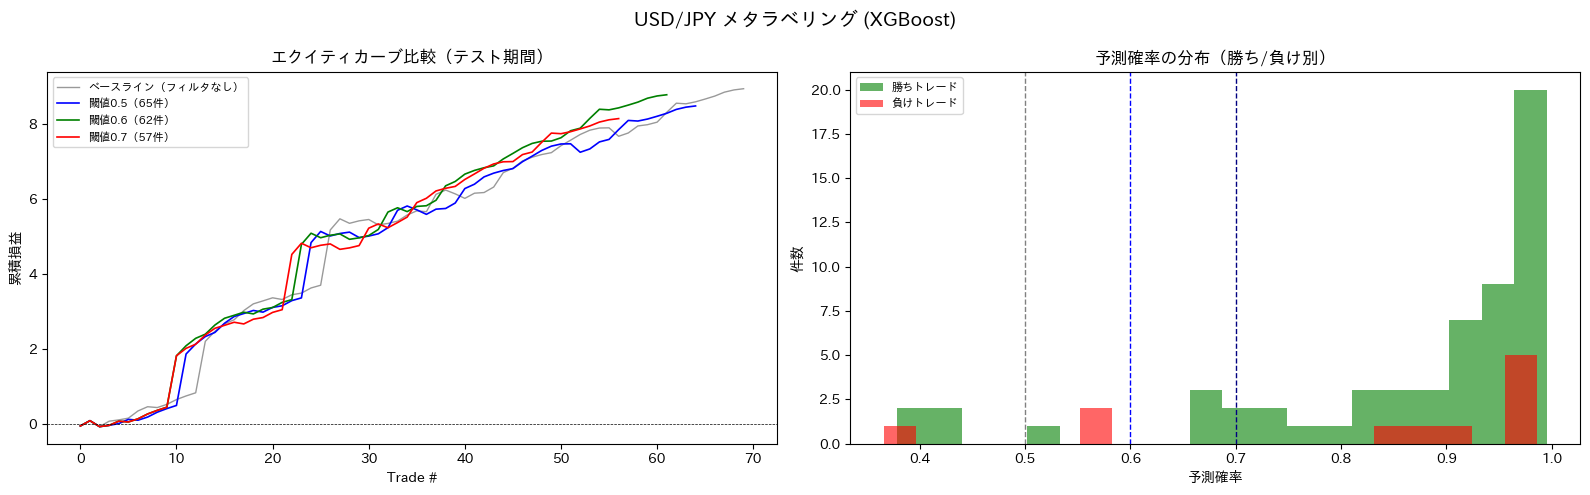

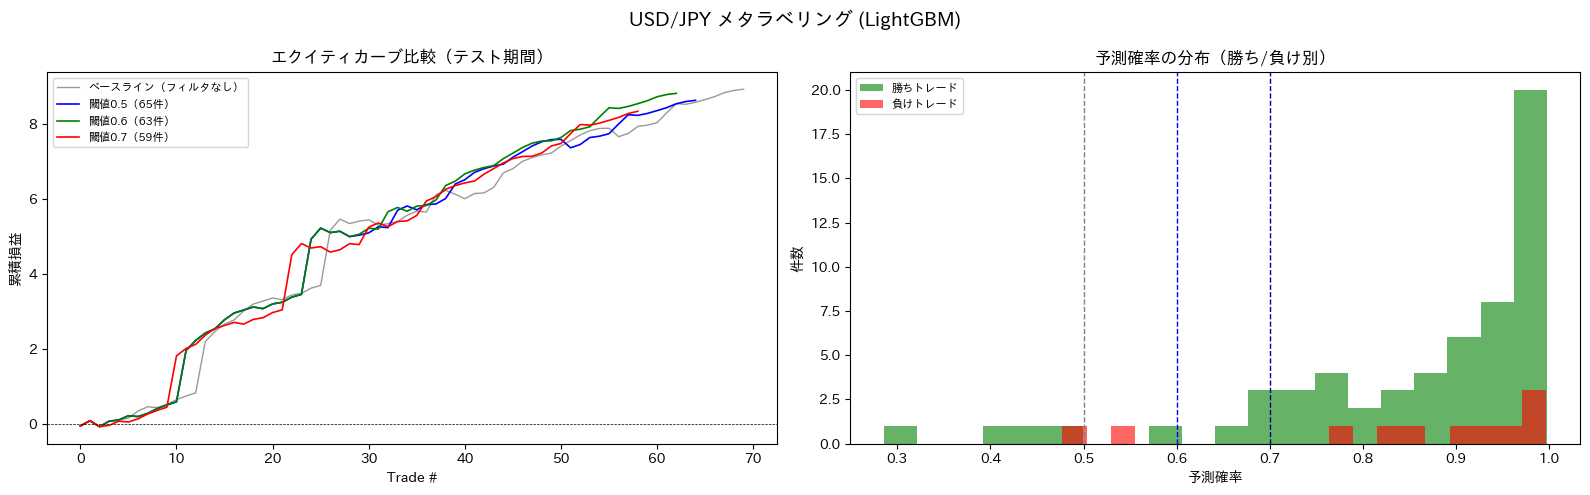

In [15]:
plot_meta_results(test_usdjpy, results_usdjpy, "USD/JPY", model_name="XGBoost")
plot_meta_results(test_usdjpy, results_usdjpy, "USD/JPY", model_name="LightGBM")

### ETH/JPY 結果

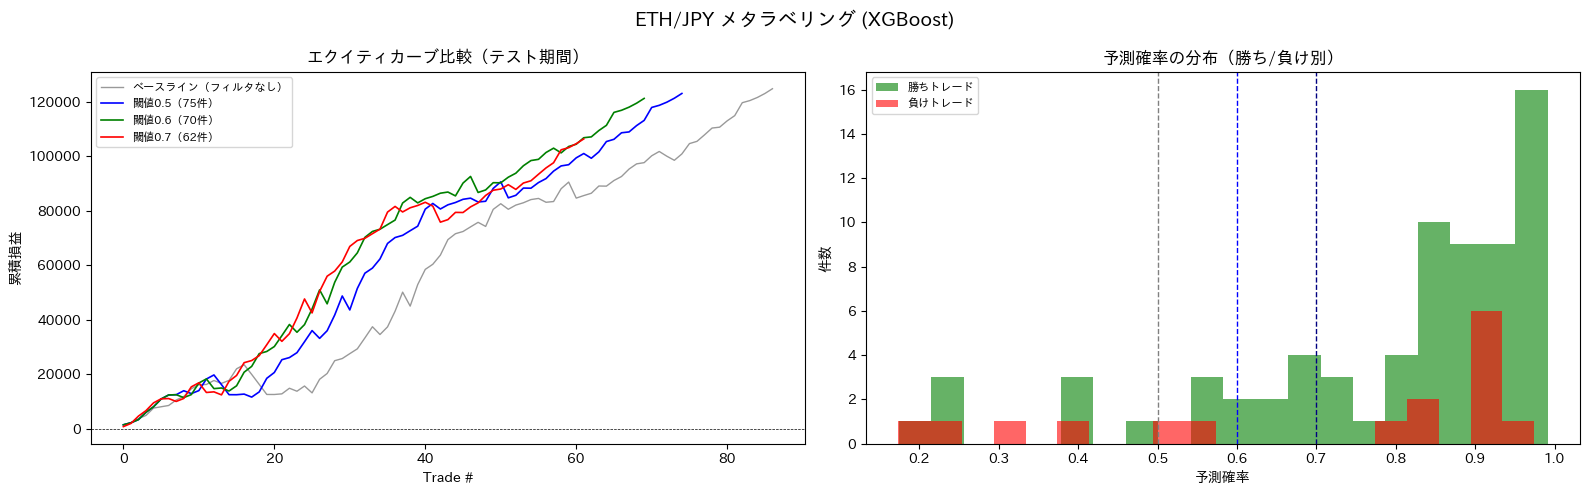

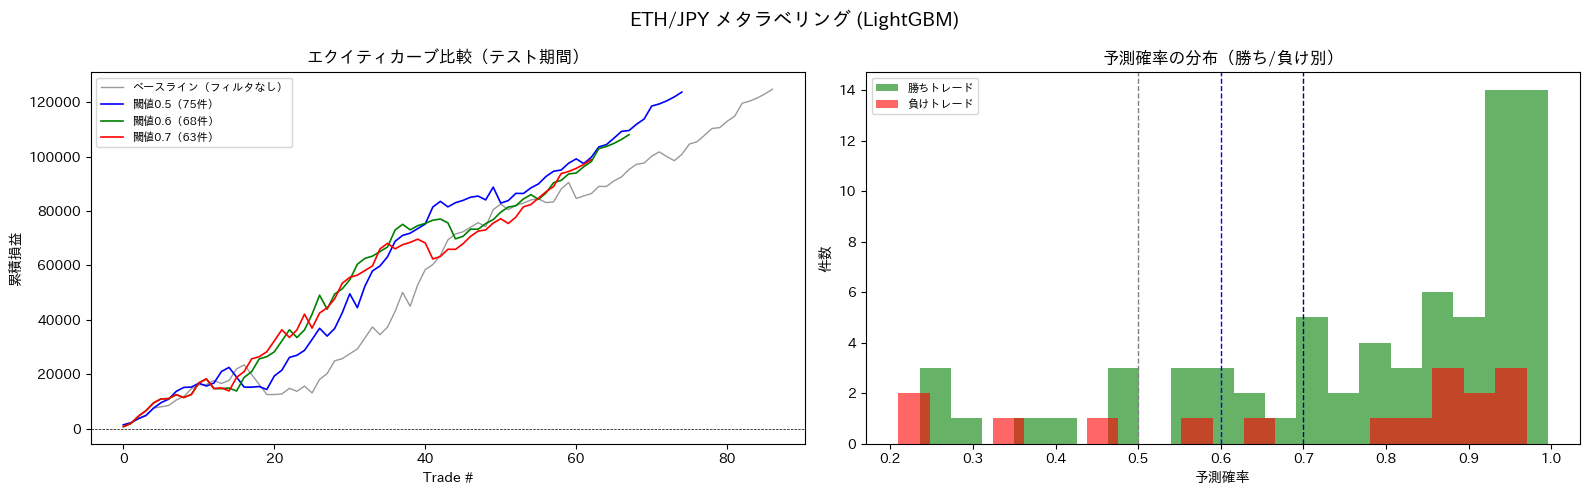

In [16]:
plot_meta_results(test_eth, results_eth, "ETH/JPY", model_name="XGBoost")
plot_meta_results(test_eth, results_eth, "ETH/JPY", model_name="LightGBM")

## 7. 比較サマリー

In [17]:
def print_summary(results, symbol):
    print(f"\n{'='*70}")
    print(f"{symbol} メタラベリング 比較サマリー")
    print(f"  モデル x 閾値 別テスト期間成績")
    print(f"{'='*70}")
    print(f"  {'モデル':<12} {'閾値':<8} {'トレード数':<12} {'勝率%':<10} {'総損益':<16} {'PF'}")
    print(f"  {'-'*65}")
    for (model_name, threshold), r in sorted(results.items()):
        print(f"  {model_name:<12} {threshold:<8} {r['trades']:<12} "
              f"{r['win_rate']:.1f}%{'':5} {r['total_pnl']:<16.4f} {r['profit_factor']:.3f}")
    print(f"{'='*70}")
    print("* テスト期間は全データの後半30%（時系列順）。")


print_summary(results_usdjpy, "USD/JPY")
print_summary(results_eth,    "ETH/JPY")


USD/JPY メタラベリング 比較サマリー
  モデル x 閾値 別テスト期間成績
  モデル          閾値       トレード数        勝率%        総損益              PF
  -----------------------------------------------------------------
  LightGBM     0.5      65           84.6%      8.6330           10.508
  LightGBM     0.6      63           85.7%      8.8190           13.912
  LightGBM     0.7      59           84.7%      8.3410           13.212
  XGBoost      0.5      65           84.6%      8.4700           9.428
  XGBoost      0.6      62           87.1%      8.7680           14.285
  XGBoost      0.7      57           86.0%      8.1330           13.323
* テスト期間は全データの後半30%（時系列順）。

ETH/JPY メタラベリング 比較サマリー
  モデル x 閾値 別テスト期間成績
  モデル          閾値       トレード数        勝率%        総損益              PF
  -----------------------------------------------------------------
  LightGBM     0.5      75           84.0%      123756.6610      5.341
  LightGBM     0.6      68           83.8%      108112.8660      5.356
  LightGBM     0.7      63           84.1